## Tipos de Datos

En los años 60, Stanley Smith (1906-1973) creó 4 escalas de medición:

Tipos Categóricos
- **Ordinal**: son datos cuantitativos en los que existen variables en categorías ordenadas. 1 - Muy Bueno, 2 - Bueno, 3 - Regular, 4 - Malo, 5 - Muy Malo. En los datos ordinales, las distancias entre datos no siempre es uniforme. 
- **Nominal**: Los datos nominales son datos con etiquetas o con nombres que definen categorías.  Por ejemplo, Costarricense, Nicaragüense, Panameño y Honduerno, son gentilicios (tipos nominales) para describir el origen de una persona. 

Tipos Numéricos
- **Ratio**: Datos que tienen un cero definido. El crimen en la ciudad bajo un 10%. 
- **Intervalo**: En este tipo de datos, existe una distancia uniforme entre los datos. Por ejemplo la definición de un intervalo de [0,1] donde donde los valores permitidos son 0.1, 0.2, 0.3,...,0.8,0.9. En python, comúnmente se utilizan los rangos, para trabajar con intervalos de cualquier tipo.

Estas 4 categorías que hemos separado en 2 áreas: categóricos y numéricos, pues no representan todos los datos que podemos encontrar hoy en día. Por tanto, vamos a agregar más tipos como valores continuos, binarios, texto, series de tiempo e imágenes, entre otros.

Otros tipos de datos:

- **Numéricos - Continuo**: es el tipo de dato que toma cualquier valor en un rango determinado. Por ejemplo la temperatura puede ser de 37 grados o bien de 38. También puede ser de 37.51, 37.66 y 37.88. 
- **Numéricos - Discreto**: es un tipo de dato que solamente puede tomar un valor de un mínimo conjunto numerable. Por tanto no acepta cualquier valor, solo puede tomar uno que pertenezca al conjunto. Por ejemplo, una calificación de A, B, C, D o E para un estudiante es un tipo de variable discreta, al igual que el número de títulos de que tiene la liga (29). No existe el número 29.5. 
- **Únicos**: son aquellos valores que no establecen una relación con otras variables, y usualmente tienen una alta cardinalidad. Por ejemplo un GUID o bien un número de cédula. 
- **Binarios**: Es un tipo de dato nominal con 2 categorías. A o B, bueno o malo, cierto o falso, 1 o 0.
- **Conteo**: es una variable que describe una distribución. Por ejemplo, después de una encuesta sabemos que tenemos una calificación de 500 muy buenos, 300 regulares y 100 malos.
- **Tiempo**: las variables de tiempo permiten almacenar información sobre horas, minutos, segundos, milisegundos, meses, días y años.  Estas variables están sujetas a numerosas transformaciones para poder expresar el tiempo con distintos formatos. Por ejemplo dd/MM/yyyyThh:mm:ss o bien yyyy/MMM - hh:mm
- **Texto**: representa una variable de tipo String que puede contener una cantidad limitada de caracteres alfanuméricos, espacios y caracteres especiales. “Hoy es 10 de enero de 2040, me he despertado sin saber quien soy...”
- **Imágenes**: es un tipo de dato que normalmente almacena información en arreglos o estructuras rectangulares (matrices) 	que almacenan información de pixeles y sus canales de color (RGB). Una imagen puede ser descrita como 3 matrices; una para cada canal. Los diferentes formatos de imagen, por ejemplo PNG o JPG permiten almacenar información adicional para lograr efectos distintos (transparencias). 
- **Series de Tiempo**: representa una secuencia de datos que han sido determinados en un momento del tiempo; por tanto su orden es cronológico. Por ejemplo, el precio de las acciones de la bolsa de Apple (AAPL) son series temporales, ya que el valos de una acción representa el valor en un momento del día únicamente.El conjunto de precios a través del día, definen un ejemplo de serie temporal.


In [13]:
import numpy as np
import pandas as pd

## Algunos Ejemplos en Python

#### Datos Categoricos

In [40]:
from sklearn.preprocessing import OrdinalEncoder

enc = OrdinalEncoder()

X = np.array(["Muy Bueno", "Bueno", "Regular", "Malo", "Muy Malo"]).reshape(-1,1)
enc.fit(X)

print(enc.transform(X))
print("")
print(enc.inverse_transform(np.array([3,1]).reshape(-1,1)))

[[2.]
 [0.]
 [4.]
 [1.]
 [3.]]

[['Muy Malo']
 ['Malo']]


#### Ordinal Encoding en Pandas DataFrame

In [ ]:

datos = [
    {'Nombre': 'Juan', 'Provincia': 'Heredia', 'Equipo': 'Limon FC'},
    {'Nombre': 'Michael', 'Provincia': 'San Jose', 'Equipo': 'Liga'},
    {'Nombre': 'Ana', 'Provincia': 'San Jose', 'Equipo': 'Saprissa'},
    {'Nombre': 'Jualia', 'Provincia': 'Alajuela', 'Equipo': 'Perez'}
]

df = pd.DataFrame(datos)

df

,Nombre,Provincia,Equipo
0,Juan,Heredia,Limon FC
1,Michael,San Jose,Liga
2,Ana,San Jose,Saprissa
3,Jualia,Alajuela,Perez


In [43]:
enc = OrdinalEncoder()
enc.fit(df[["Provincia","Equipo"]])

df[["Provincia","Equipo"]] = enc.transform(df[["Provincia","Equipo"]])

# Nota: df.Equipo es de typo dtype: object...
#df.Equipo 

#### Categoricos con Pandas 

In [46]:
import pandas as pd

datos_cat = [
    {'Nombre': 'Juan', 'Provincia': 'Heredia', 'Equipo': 'Limon FC'},
    {'Nombre': 'Michael', 'Provincia': 'San Jose', 'Equipo': 'Liga'},
    {'Nombre': 'Ana', 'Provincia': 'San Jose', 'Equipo': 'Saprissa'},
    {'Nombre': 'Jualia', 'Provincia': 'Alajuela', 'Equipo': 'Perez'}
]

df = pd.DataFrame(datos_cat)

df["Provincia"] = df["Provincia"].astype('category')
df["Equipo"] = df["Equipo"].astype('category')

print("Las categorias de los equipos son", df["Equipo"].cat.categories.unique())
print(" ")
print("Tenemos los siguientes conteos por categoria:\n", df["Equipo"].value_counts())

Las categorias de los equipos son Index(['Liga', 'Limon FC', 'Perez', 'Saprissa'], dtype='str')
 
Tenemos los siguientes conteos por categoria:
 Equipo
Liga        1
Limon FC    1
Perez       1
Saprissa    1
Name: count, dtype: int64


In [47]:
import pandas as pd

datos_dummy = [
    {'Nombre': 'Juan', 'Provincia': 'Heredia'},
    {'Nombre': 'Michael', 'Provincia': 'San Jose'},
    {'Nombre': 'Ana', 'Provincia': 'San Jose'},
    {'Nombre': 'Jualia', 'Provincia': 'Alajuela'}
]

df = pd.DataFrame(datos_dummy)
dummies = pd.get_dummies(df.Provincia, prefix="provincia")

df = df.drop('Provincia', axis=1)
df = df.join(dummies)
df

,Nombre,provincia_Alajuela,provincia_Heredia,provincia_San Jose
0,Juan,False,True,False
1,Michael,False,False,True
2,Ana,False,False,True
3,Jualia,True,False,False


#### Intervalos con Pandas

In [49]:
# Intervalo (0, 5]
intervalo = pd.Interval(left=0, right=5)

x = 1.99
if(x in intervalo):
    print(x,'si esta en el intervalo')
else:
    print(x,'no esta en el intervalo')

1.99 si esta en el intervalo


In [13]:
# Intervalo de tiempo! 
a2017 = pd.Interval(pd.Timestamp('2017-01-01 00:00:00'),pd.Timestamp('2018-01-01 00:00:00'),closed='right')

x = pd.Timestamp('2019-05-05 00:00:00')
if(x in a2017):
    print(x,'si esta en el intervalo')
else:
    print(x,'no esta en el intervalo')

2019-05-05 00:00:00 no esta en el intervalo


#### Variable Conteo

In [ ]:
import collections

c = collections.Counter('abcdaabbbbbabababababababbaabbbbbbbabababababacccccccdcdcdcdcdcdca')

c

Counter({'b': 26, 'a': 19, 'c': 14, 'd': 11})

In [52]:
c = collections.Counter(np.array(['a','a','a','b']))

c

Counter({np.str_('a'): 3, np.str_('b'): 1})

#### Variable de Tiempo

In [56]:
from datetime import datetime 
from datetime import timedelta

# agregar un dia
print(datetime.now() + timedelta(days=1))

# agregar 10 minutos
print(datetime.now() + timedelta(minutes=10))

# restar 1 hora y 30 minutos
print(datetime.now() - timedelta(hours=1,minutes=30))

2026-06-10 21:00:11.926970
2026-06-09 21:10:11.928233
2026-06-09 19:30:11.928463


In [54]:
tiempo = np.array(["2019-05-05T01:00:00","2019-06-05T14:40:00","2019-07-05T06:50:00"])

# se recorre el arreglo y se transforma cada elemento en DateTime
tiempo_f = [datetime.strptime(t, '%Y-%m-%dT%H:%M:%S') for t in tiempo]

tiempo_f

[datetime.datetime(2019, 5, 5, 1, 0),
 datetime.datetime(2019, 6, 5, 14, 40),
 datetime.datetime(2019, 7, 5, 6, 50)]

#### Imagenes

In [18]:
#!pip3 install scikit-image==0.16.1

C:\Users\doria\AppData\Local\Temp\ipykernel_16676\210718666.py:5: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img)


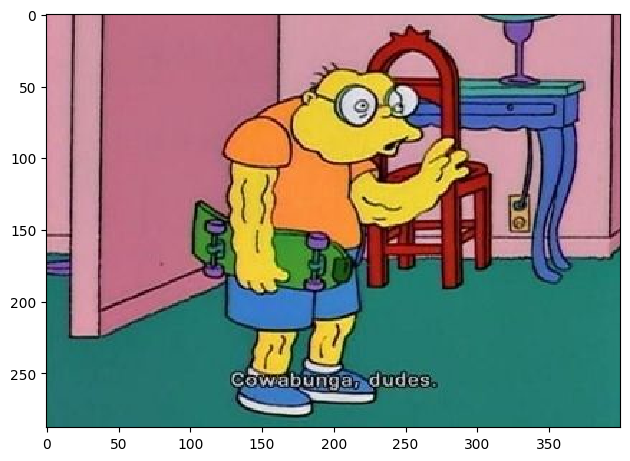

In [24]:
from skimage import io
import matplotlib.pyplot as plt

img = io.imread("img/jtopo.jpg")
io.imshow(img)
plt.show()

C:\Users\doria\AppData\Local\Temp\ipykernel_16676\1095759333.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(rgb2gray(img))


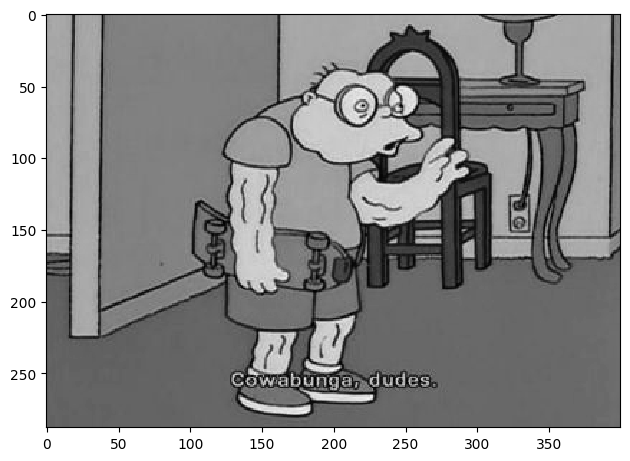

In [4]:
from skimage.color import rgb2gray
io.imshow(rgb2gray(img))
plt.show()

C:\Users\doria\AppData\Local\Temp\ipykernel_16676\3416542256.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(rgb2hsv(img))


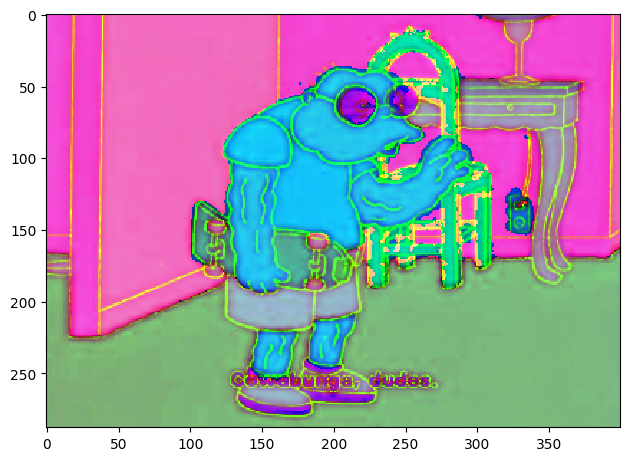

In [5]:
from skimage.color import rgb2hsv # rgb2hsv
io.imshow(rgb2hsv(img))
plt.show()

#### Series Temporales

In [57]:

import matplotlib.pyplot as plt

df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/a10.csv', parse_dates=['date'], index_col='date')

def plot_df(df, x, y, title="", xlabel='Date', ylabel='Value', dpi=100):
    plt.figure(figsize=(10,5), dpi=dpi)
    plt.plot(x, y, color='tab:red')
    # gca = get current axes
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()


df.head()

,value
date,
1991-07-01,3.526591
1991-08-01,3.180891
1991-09-01,3.252221
1991-10-01,3.611003
1991-11-01,3.565869


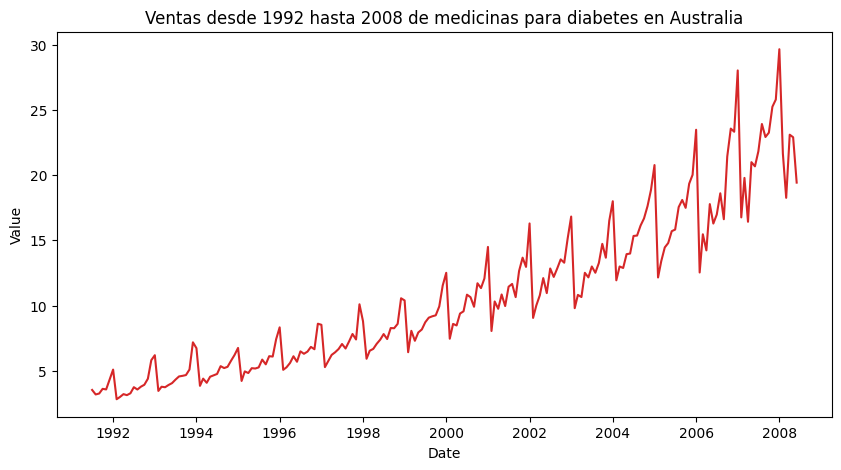

In [9]:
plot_df(df, x=df.index, y=df.value, 
        title='Ventas desde 1992 hasta 2008 de medicinas para diabetes en Australia')